In [16]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)
#from google.colab import drive
#drive.mount('/content/drive')

# Baseline model: logistic regressor

In [3]:
#df = pd.read_parquet('/content/drive/MyDrive/SB/SB_Project/classification_ring/data/processed/data_ml.parquet')
df = pd.read_parquet('./classification_ring/data/processed/data_ml.parquet')

df.head()

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_a5,t_3di_state,t_3di_letter,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
0,1u9c,A,172,,S,H,0.354,-1.001,-0.749,-0.228,...,-0.912,17.0,R,1,0,0,0,0,0,1
1,1u9c,A,184,,G,-,0.250,-2.102,-3.018,-0.384,...,-1.853,19.0,T,1,0,0,0,0,0,0
2,1u9c,A,10,,T,-,0.000,-1.252,2.751,-0.032,...,-3.242,12.0,M,1,0,0,0,0,0,0
3,1u9c,A,133,,V,T,0.021,-1.076,-0.664,-1.337,...,1.313,15.0,P,0,0,0,0,0,0,1
4,1u9c,A,146,,G,T,0.548,1.315,0.127,-0.384,...,2.064,6.0,G,1,0,0,0,0,0,0


#### Split train/test/validation by pdb_id

In [4]:
#print(df.columns.tolist())
#print(df.dtypes)
#looking at the column names

Defining the columns

In [5]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

#Numerical features
num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    't_3di_state'
]

#Categorical features
cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]

print("Label distribution:")
print(df[label_cols].sum().sort_values(ascending=False))

Label distribution:
HBOND        1055929
VDW           737061
PIPISTACK      38283
IONIC          35391
PICATION        8885
SSBOND          2100
PIHBOND         1790
dtype: int64


Spliting

In [9]:
#avoiding data leakage
pdb_ids = df['pdb_id'].unique().to_numpy()
print(f"Total unique PDBs: {len(pdb_ids)}")

#using 70% train, 15% val, 15% test
train_pdbs, temp_pdbs = train_test_split(pdb_ids, test_size=0.30, random_state=42)
val_pdbs, test_pdbs   = train_test_split(temp_pdbs, test_size=0.50, random_state=42)

train_df = df[df['pdb_id'].isin(train_pdbs)].reset_index(drop=True)
val_df   = df[df['pdb_id'].isin(val_pdbs)].reset_index(drop=True)
test_df  = df[df['pdb_id'].isin(test_pdbs)].reset_index(drop=True)

print(f"Train: {len(train_df)} rows, {len(train_pdbs)} PDBs")
print(f"Val:   {len(val_df)} rows, {len(val_pdbs)} PDBs")
print(f"Test:  {len(test_df)} rows, {len(test_pdbs)} PDBs")

Total unique PDBs: 3827
Train: 999083 rows, 2678 PDBs
Val:   238810 rows, 574 PDBs
Test:  214518 rows, 575 PDBs


Preparation of X and Y

In [10]:
feature_cols = num_features + cat_features

X_train = train_df[feature_cols]
Y_train = train_df[label_cols]

X_val = val_df[feature_cols]
Y_val = val_df[label_cols]

X_test = test_df[feature_cols]
Y_test = test_df[label_cols]

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (999083, 22)
Y_train shape: (999083, 7)


Preproccessing to clean the features

In [13]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer # apply different preprocessing steps to different columns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier # train a separate classifier for each output label (one vs rest)
from sklearn.impute import SimpleImputer # fills in missing values with a specified strategy (mean, median, mode, etc.)
#Imputing was necessary because we of NaN vaues
# Numerical:impute with median then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical:impute with most frequent,then encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # handle_unknown='ignore' ensures that if a category appears in the test set that wasn't seen in the training set, it won't cause an error. Instead, it will be ignored and encoded as all zeros.
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

lr_model = MultiOutputClassifier(
    LogisticRegression(
        class_weight='balanced', # helps to handle class imbalance by adjusting the weights inversely proportional to class frequencies in the input data. Model learns to pay more attention to the minority class.
        max_iter=1000,
        random_state=42
    )
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lr_model)
    ],
    verbose = True # prints some logging, which might be useful to see the progress of the training
)

print("Pipeline built successfully")

Pipeline built successfully


Train

In [14]:
print("Training")
pipeline.fit(X_train, Y_train)
print("Training complete!")

Training
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   2.8s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  31.6s
Training complete!


---
Evaluation of validation set

In [28]:
from sklearn.metrics import classification_report, f1_score
import numpy as np
Y_pred = pipeline.predict(X_val)

print("=" * 60)
print("For each Class Results on VALIDATION SET")
print("=" * 60)

for i, label in enumerate(label_cols):
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val.iloc[:, i],
        Y_pred[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))
macro_f1 = f1_score(Y_val, Y_pred, average='macro', zero_division=0)
micro_f1 = f1_score(Y_val, Y_pred, average='micro', zero_division=0)
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")

For each Class Results on VALIDATION SET

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.39      0.59      0.47     65125
     present       0.81      0.65      0.72    173685

    accuracy                           0.64    238810
   macro avg       0.60      0.62      0.60    238810
weighted avg       0.69      0.64      0.65    238810


--- VDW ---
              precision    recall  f1-score   support

      absent       0.56      0.58      0.57    117837
     present       0.57      0.55      0.56    120973

    accuracy                           0.56    238810
   macro avg       0.56      0.56      0.56    238810
weighted avg       0.57      0.56      0.56    238810


--- IONIC ---
              precision    recall  f1-score   support

      absent       1.00      0.90      0.94    233328
     present       0.18      0.99      0.31      5482

    accuracy                           0.90    238810
   macro avg       0.59      0.94      0.63 

In [21]:
target_names = label_cols

# get predicted probabilities for each class
y_proba_list = pipeline.predict_proba(X_test) # list of #target_names arrays, each of shape (n_samples, 2) containing yes/no probabilities

# column of probabilities for the "present" class (index 1) for each label
y_scores = np.array([proba[:, 1] for proba in y_proba_list]).T # shape (n_samples, n_labels)
print(y_scores.shape)
print(y_scores[:5])

(214518, 7)
[[6.30730160e-01 4.04556812e-01 9.64139870e-06 9.93648819e-10
  6.84911691e-12 2.55275602e-08 4.74830280e-03]
 [4.92170370e-01 6.16898686e-01 1.15576468e-03 5.01988970e-06
  4.46180478e-06 5.47943432e-14 1.51238189e-01]
 [4.88846591e-01 6.07129980e-01 1.92922070e-02 2.00162289e-06
  1.79062095e-08 8.93967770e-22 1.50725460e-01]
 [3.02112887e-01 6.16300538e-01 4.25516891e-06 1.54083505e-06
  2.55809067e-07 3.69005433e-13 3.18717530e-02]
 [5.37855848e-01 4.09213429e-01 7.89491572e-08 4.79751713e-07
  7.11454348e-05 3.13280958e-08 2.08117850e-01]]


Benchmark MCC and Balanced Accuracy at varying threshold, for each class

In [27]:
thresholds = np.arange(0.00, 1.01, 0.01)

results = []

for class_idx, class_name in enumerate(target_names):
    
    y_true_class = Y_test.iloc[:, class_idx] if hasattr(Y_test, "iloc") else Y_test[:, class_idx]
    y_score_class = y_scores[:, class_idx]
    
    for threshold in thresholds:
        
        y_pred_class = (y_score_class >= threshold).astype(int)
        
        mcc = matthews_corrcoef(y_true_class, y_pred_class)
        bal_acc = balanced_accuracy_score(y_true_class, y_pred_class)
        
        results.append({
            "class": class_name,
            "threshold": threshold,
            "MCC": mcc,
            "balanced_accuracy": bal_acc
        })

threshold_results = pd.DataFrame(results)

threshold_results.head()

,class,threshold,MCC,balanced_accuracy
0,HBOND,0.00,0.0,0.5
1,HBOND,0.01,0.0,0.5
2,HBOND,0.02,0.0,0.5
3,HBOND,0.03,0.0,0.5
4,HBOND,0.04,0.0,0.5


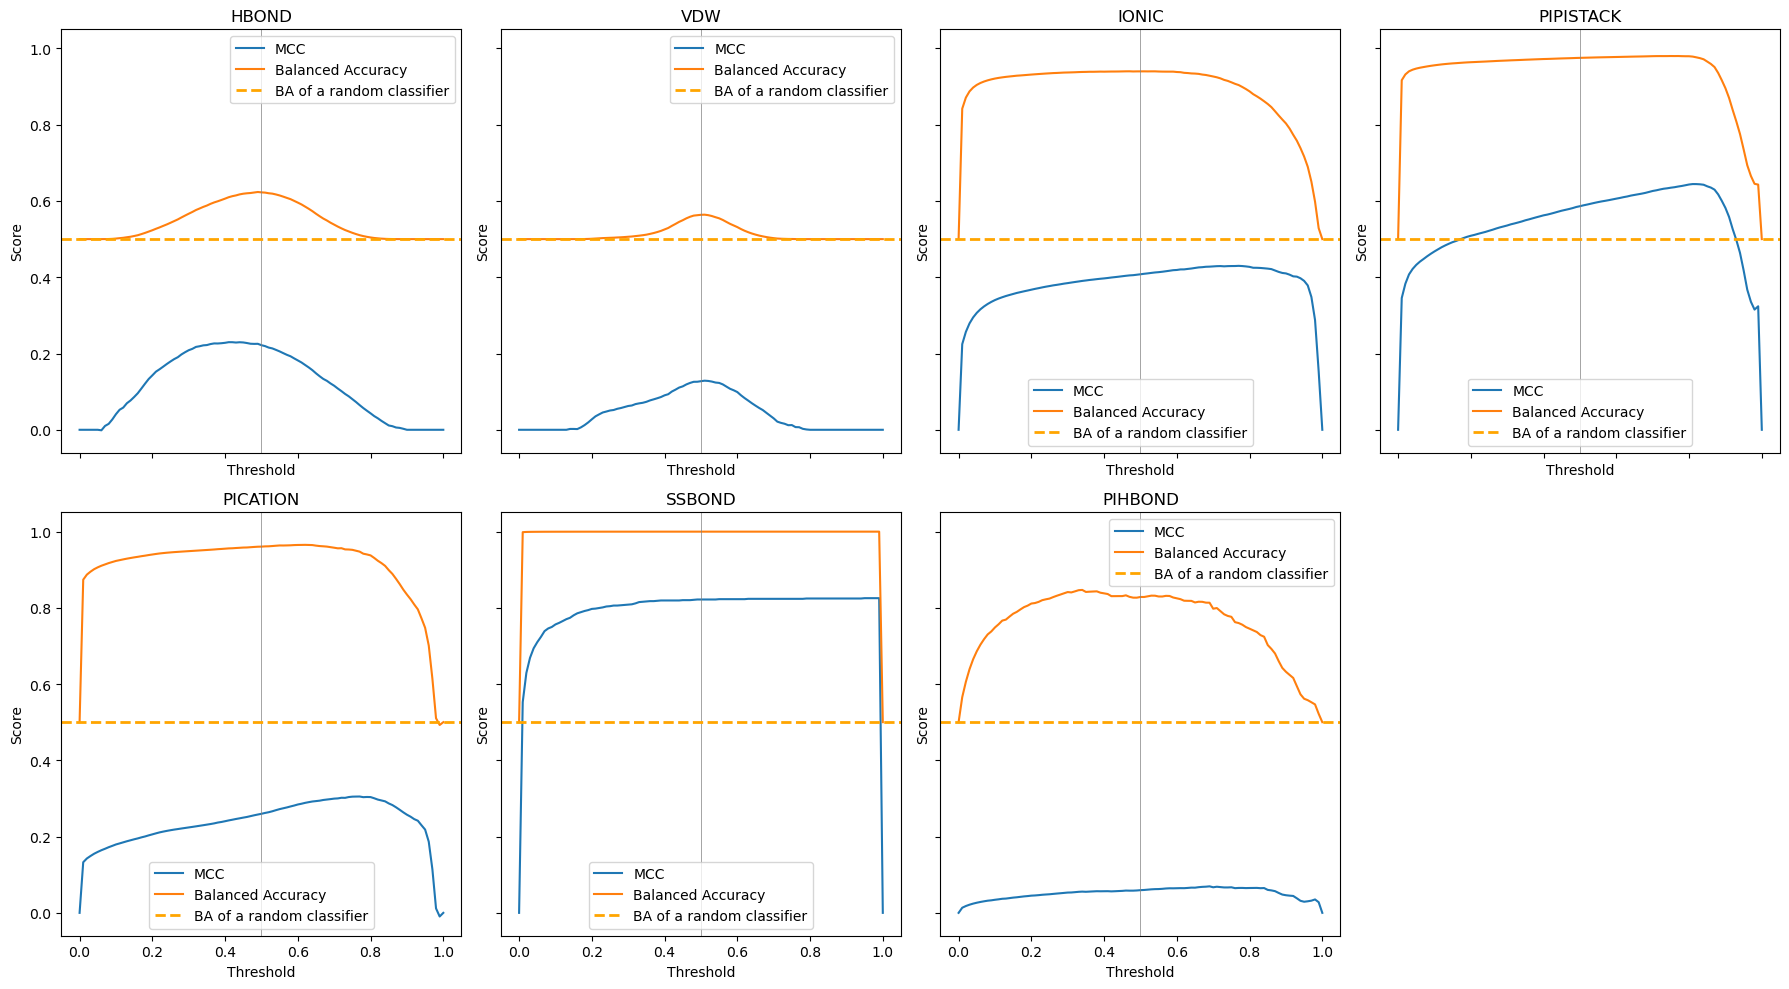

In [30]:
# plot MCC and balanced accuracy vs threshold for each class

fig, axes = plt.subplots(2, len(target_names)//2 + 1, figsize=(18, 10),
                         sharex=True, sharey=True)
axes = axes.flatten()

axes[-1].axis('off') 

for class_idx, class_name in enumerate(target_names):
    ax = axes[class_idx]
    class_results = threshold_results[threshold_results["class"] == class_name]
    ax.plot(class_results["threshold"], class_results["MCC"], label="MCC")
    ax.plot(class_results["threshold"], class_results["balanced_accuracy"], label="Balanced Accuracy")
    ax.axvline(x = 0.5, color = 'grey', lw = 0.5, ls = "solid")
    ax.axhline(y = 0.5, color = 'orange', lw = 2, ls = "dashed", label = "BA of a random classifier")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"{class_name}")
    ax.legend()
plt.tight_layout()
plt.show()

---
Test Imbalance

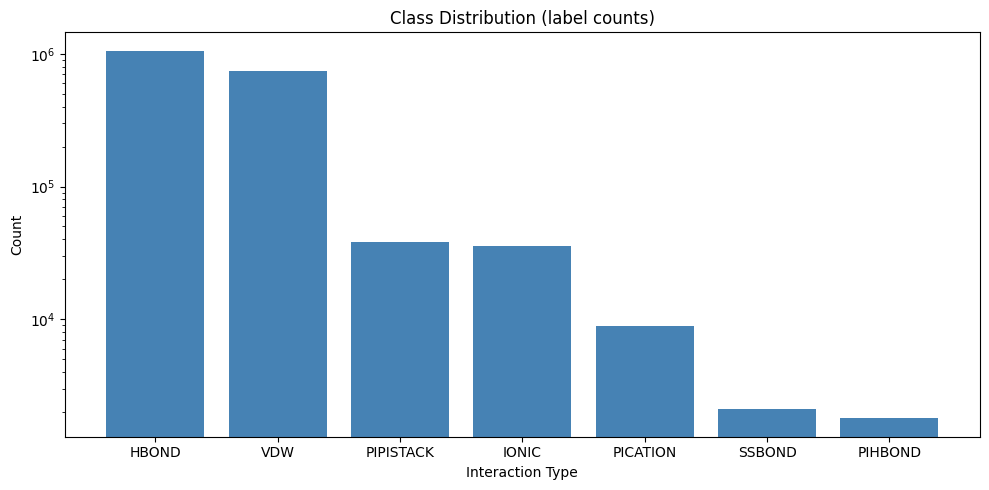

HBOND        1055929
VDW           737061
PIPISTACK      38283
IONIC          35391
PICATION        8885
SSBOND          2100
PIHBOND         1790
dtype: int64


In [29]:
import matplotlib.pyplot as plt

label_counts = df[label_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color='steelblue')
plt.title("Class Distribution (label counts)")
plt.ylabel("Count")
plt.xlabel("Interaction Type")
plt.yscale('log')#seeing log scale because very imbalanced
plt.tight_layout()
plt.show()

print(label_counts)

Saving test for later

In [51]:
os.makedirs("classification_ring/data/processed", exist_ok=True)

train_df.to_parquet("classification_ring/data/processed/train.parquet", index=False)
val_df.to_parquet("classification_ring/data/processed/val.parquet", index=False)
test_df.to_parquet("classification_ring/data/processed/test.parquet", index=False)

print("Splits saved successfully.")
print("DO NOT touch test.parquet until final evaluation pliz!")

Splits saved successfully.
DO NOT touch test.parquet until final evaluation pliz!


---
---

### Further diagnostics for the one-vs-rest logistic classifier

Looking at the *scores* distirbutions: which classes are most clearly linearly separated? These plots should complement and confirm the BA plots.

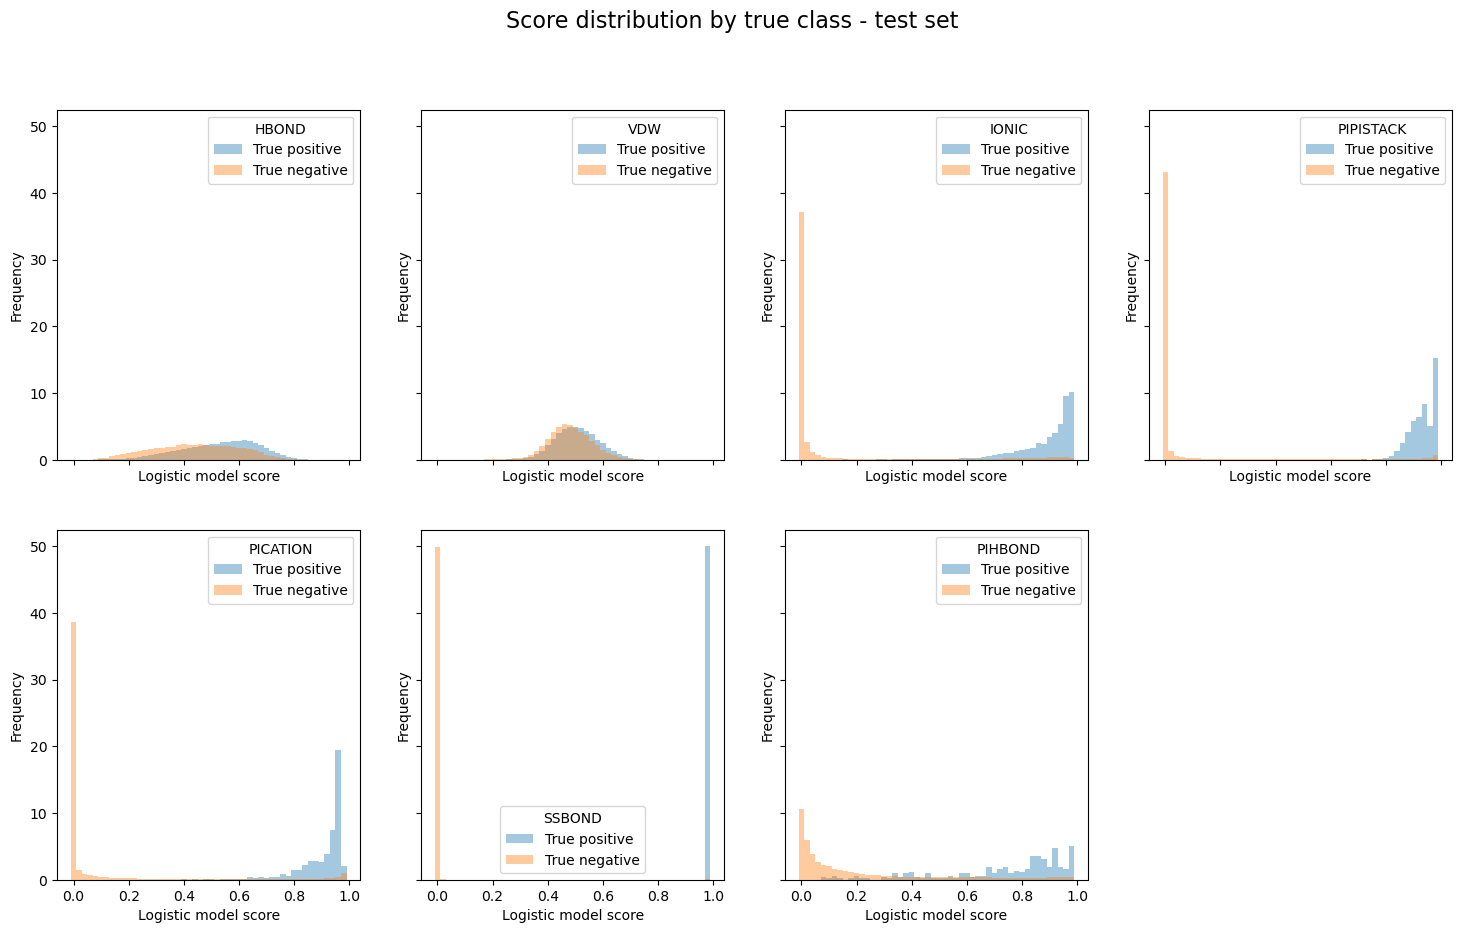

In [42]:

fig, axes = plt.subplots(2, len(target_names)//2 + 1, figsize=(18, 10),
                         sharex=True, sharey=True)

plt.suptitle("Score distribution by true class - test set", fontsize=16)
axes = axes.flatten()
axes[-1].axis('off') 


for class_idx, class_name in enumerate(target_names):
    y_true_class = Y_test.iloc[:, class_idx] if hasattr(Y_test, "iloc") else Y_test[:, class_idx]
    scores = y_scores[:, class_idx]
    positives = scores[y_true_class == 1]
    negatives = scores[y_true_class == 0]
    poscounts, posbins = np.histogram(positives, bins=50, range=(0, 1), density=True)
    negcounts, negbins = np.histogram(negatives, bins=50, range=(0, 1), density=True)
    ax = axes[class_idx]
    ax.bar(posbins[:-1], poscounts, width=np.diff(posbins), label="True positive", alpha=0.4)
    ax.bar(negbins[:-1], negcounts, width=np.diff(negbins), label="True negative", alpha=0.4)
    ax.set_xlabel("Logistic model score")
    ax.set_ylabel("Frequency")
    ax.legend(title = f"{target_names[class_idx]}")

plt.show()

This plot shows, even more clearly than the Balanced Accuracy curve,  that HBOND and VDW are not clearly linearly separated. Indeed, the logistic score is the composition of the sigmoid with a linear map

$$
score(x) = \sigma \left(\sum_{i}^{n.features} w_i x_i + w_0 \right)
$$

and both classes get scores that range in an overlapping interval centered around $0.5$. This means that the two classes cannot be separated well with a linear boundary.

Which features where considered most important for label prediction?

In [53]:
# Extract fitted parts
preprocessor = pipeline.named_steps["preprocessor"]
classifier = pipeline.named_steps["classifier"]

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# One LogisticRegression model per class
estimators = classifier.estimators_

# Store coefficients class by class
coef_tables = {}

for class_idx, class_name in enumerate(target_names):
    model = estimators[class_idx]

    coefs = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs)
    }).sort_values("abs_coefficient", ascending=False)

    coef_tables[class_name] = coef_df

    #print(f"\nTop features for {class_name}")
    #display(coef_df.head(15))

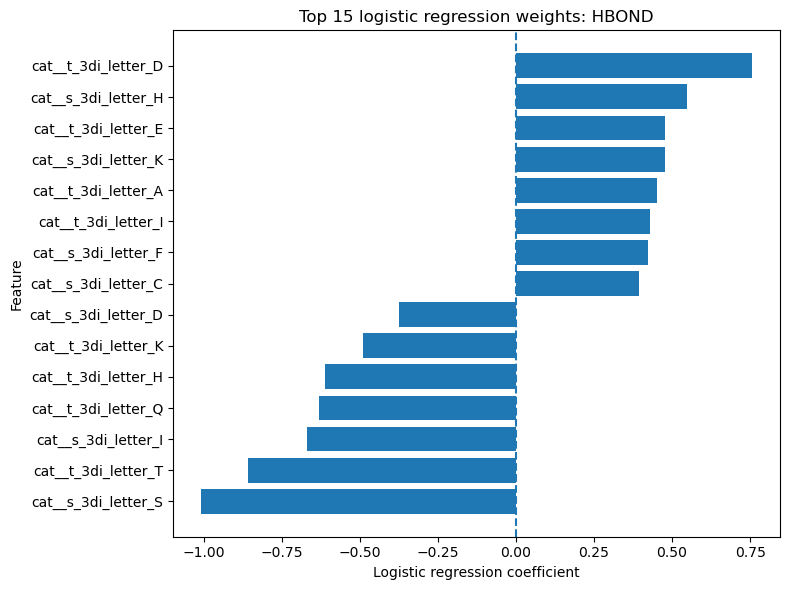

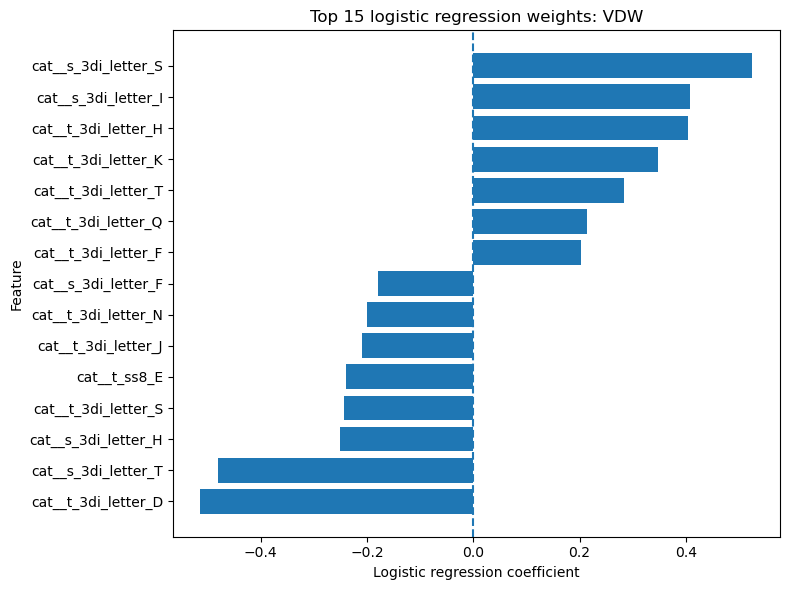

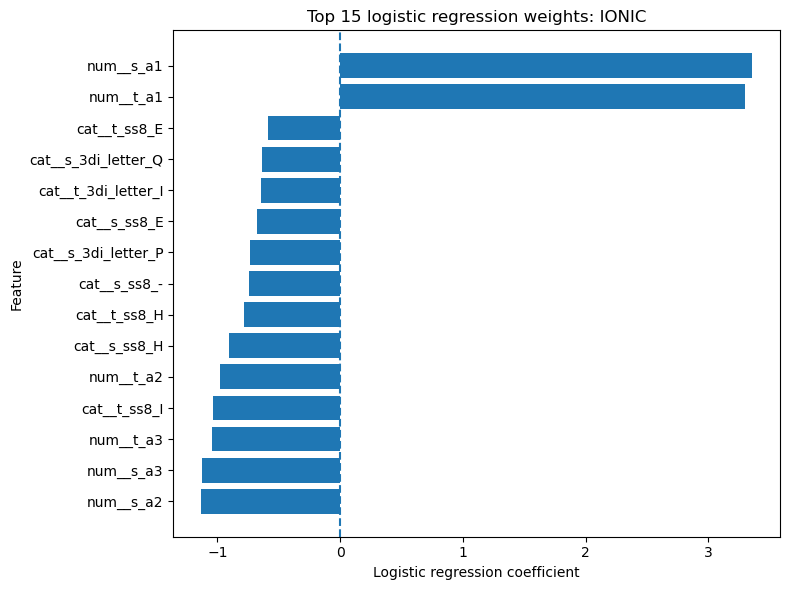

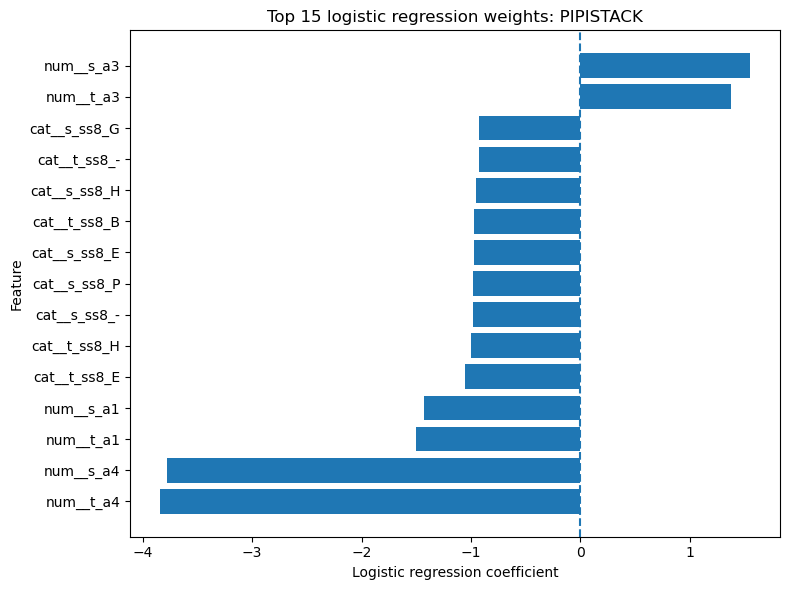

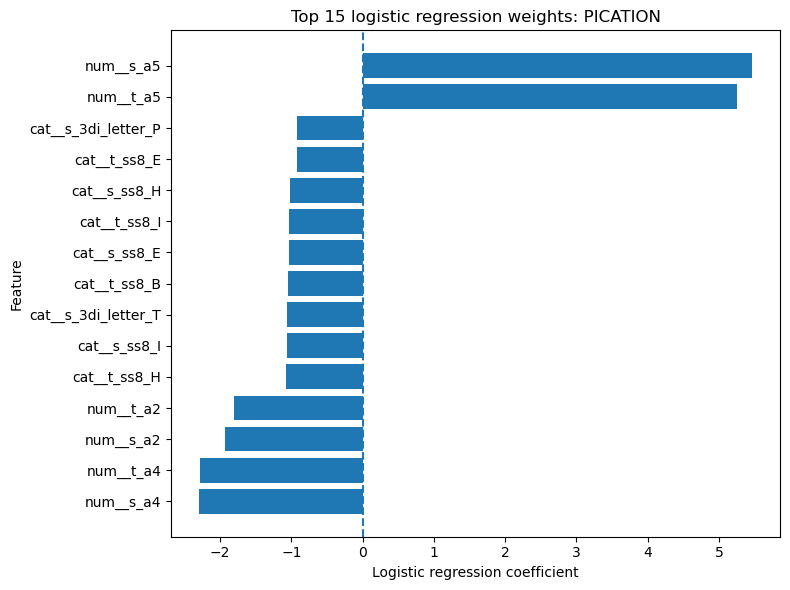

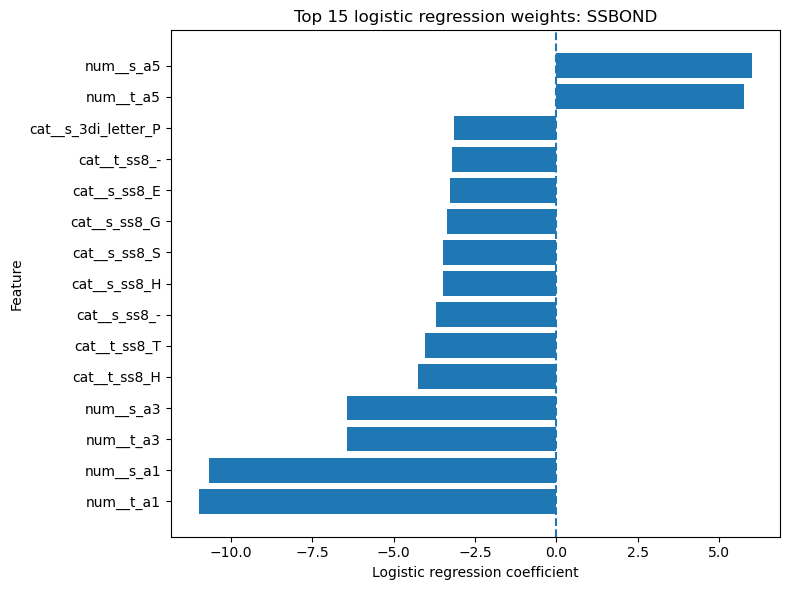

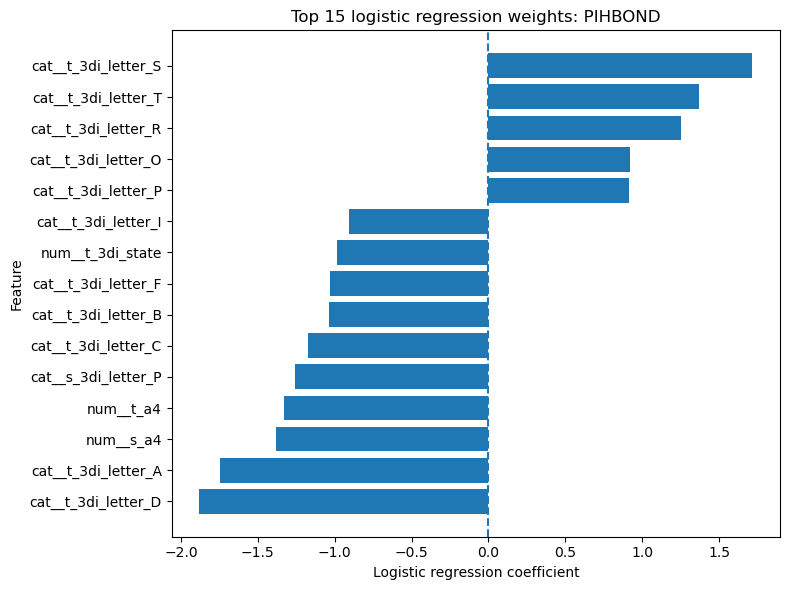

In [54]:
import matplotlib.pyplot as plt

top_n = 15

for class_name, coef_df in coef_tables.items():

    top_df = (
        coef_df
        .sort_values("abs_coefficient", ascending=False)
        .head(top_n)
        .sort_values("coefficient")
    )

    plt.figure(figsize=(8, 6))
    plt.barh(top_df["feature"], top_df["coefficient"])

    plt.axvline(0, linestyle="--")
    plt.xlabel("Logistic regression coefficient")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} logistic regression weights: {class_name}")

    plt.tight_layout()
    plt.show()